# TAE-IA · Module 6 · L18 — Evaluating and Diagnosing the Classifier

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L18 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU (needed for AST inference in Section 2.5) |
| **Drive input** | `ESC50_best.pth`, `ESC50_specs/`, `ESC-50/` |

## Learning objectives

By the end of this notebook you will be able to:
1. Compute and interpret per-class precision, recall, and F1 for a 50-class classifier
2. Generate and read a 50×50 confusion matrix heatmap
3. Identify the top confused category pairs and form acoustic hypotheses for each
4. Run AST (Audio Spectrogram Transformer) inference and compare against the EfficientNet baseline
5. Translate confusion matrix findings into concrete pipeline improvement proposals

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Models cache on the runtime disk: Drive's mount does not support the symlinks
# huggingface_hub uses, and re-downloading AST costs less than debugging OSError 95.
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
ESC50_DIR   = '/content/drive/MyDrive/TAE_IA_M6/ESC-50'
SPEC_DIR    = '/content/drive/MyDrive/TAE_IA_M6/ESC50_specs'
CKPT_PATH   = '/content/drive/MyDrive/TAE_IA_M6/ESC50_best.pth'

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    print('\nNo GPU — go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('T4 GPU required for AST inference.')

DEVICE = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)}')

# Verify prerequisites
assert os.path.exists(CKPT_PATH),  f'ESC50_best.pth not found at {CKPT_PATH} — run L17 first.'
assert os.path.exists(SPEC_DIR),   f'ESC50_specs not found — run L16 first.'
assert os.path.exists(ESC50_DIR),  f'ESC-50 dataset not found — run L16 first.'
print('All prerequisites found ✓')

Mounted at /content/drive
GPU: Tesla T4
All prerequisites found ✓


In [2]:
!pip install scikit-learn seaborn torchvision transformers librosa pillow -q

import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import IPython.display as ipd
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

print('Imports OK')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

Imports OK


---
## Section 2.1 — Rebuild Model and Collect Test Predictions

We reconstruct the exact same architecture as L17 and load the saved checkpoint.

In [3]:
meta = pd.read_csv(os.path.join(ESC50_DIR, 'meta', 'esc50.csv'))
test_meta = meta[meta['fold'] == 5].reset_index(drop=True)

# Same transform as L17 — must match exactly
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ESC50Dataset(Dataset):
    def __init__(self, meta_df, spec_dir, transform):
        self.meta = meta_df; self.spec_dir = spec_dir; self.transform = transform
    def __len__(self): return len(self.meta)
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        img = Image.open(os.path.join(self.spec_dir,
                         row['filename'].replace('.wav', '.png'))).convert('L')
        return self.transform(img), int(row['target'])

test_ds     = ESC50Dataset(test_meta, SPEC_DIR, test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
print(f'Test set: {len(test_ds)} clips  |  {len(test_loader)} batches')

Test set: 400 clips  |  13 batches


In [4]:
# Rebuild EfficientNet-B0 with the same 50-class head as L17
effnet = models.efficientnet_b0(weights=None)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 50)
effnet.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
effnet = effnet.to(DEVICE).eval()
print(f'Loaded checkpoint: {CKPT_PATH}')

# Collect all predictions
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Collecting predictions'):
        preds = effnet(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
effnet_acc  = (all_preds == all_targets).mean()

category_map  = meta.drop_duplicates('target').set_index('target')['category'].sort_index().to_dict()
category_names = [category_map[i] for i in range(50)]

print(f'\nEfficientNet-B0 test accuracy: {effnet_acc:.4f}  ({effnet_acc*100:.1f}%)')

Loaded checkpoint: /content/drive/MyDrive/TAE_IA_M6/ESC50_best.pth



EfficientNet-B0 test accuracy: 0.7550  (75.5%)


---
## Section 2.2 — Confusion Matrix

A 50×50 heatmap. Each cell $(i, j)$ counts how many clips from true class $i$ were predicted as class $j$. The diagonal is correct predictions — we want it to be bright. Off-diagonal bright cells are systematic errors.

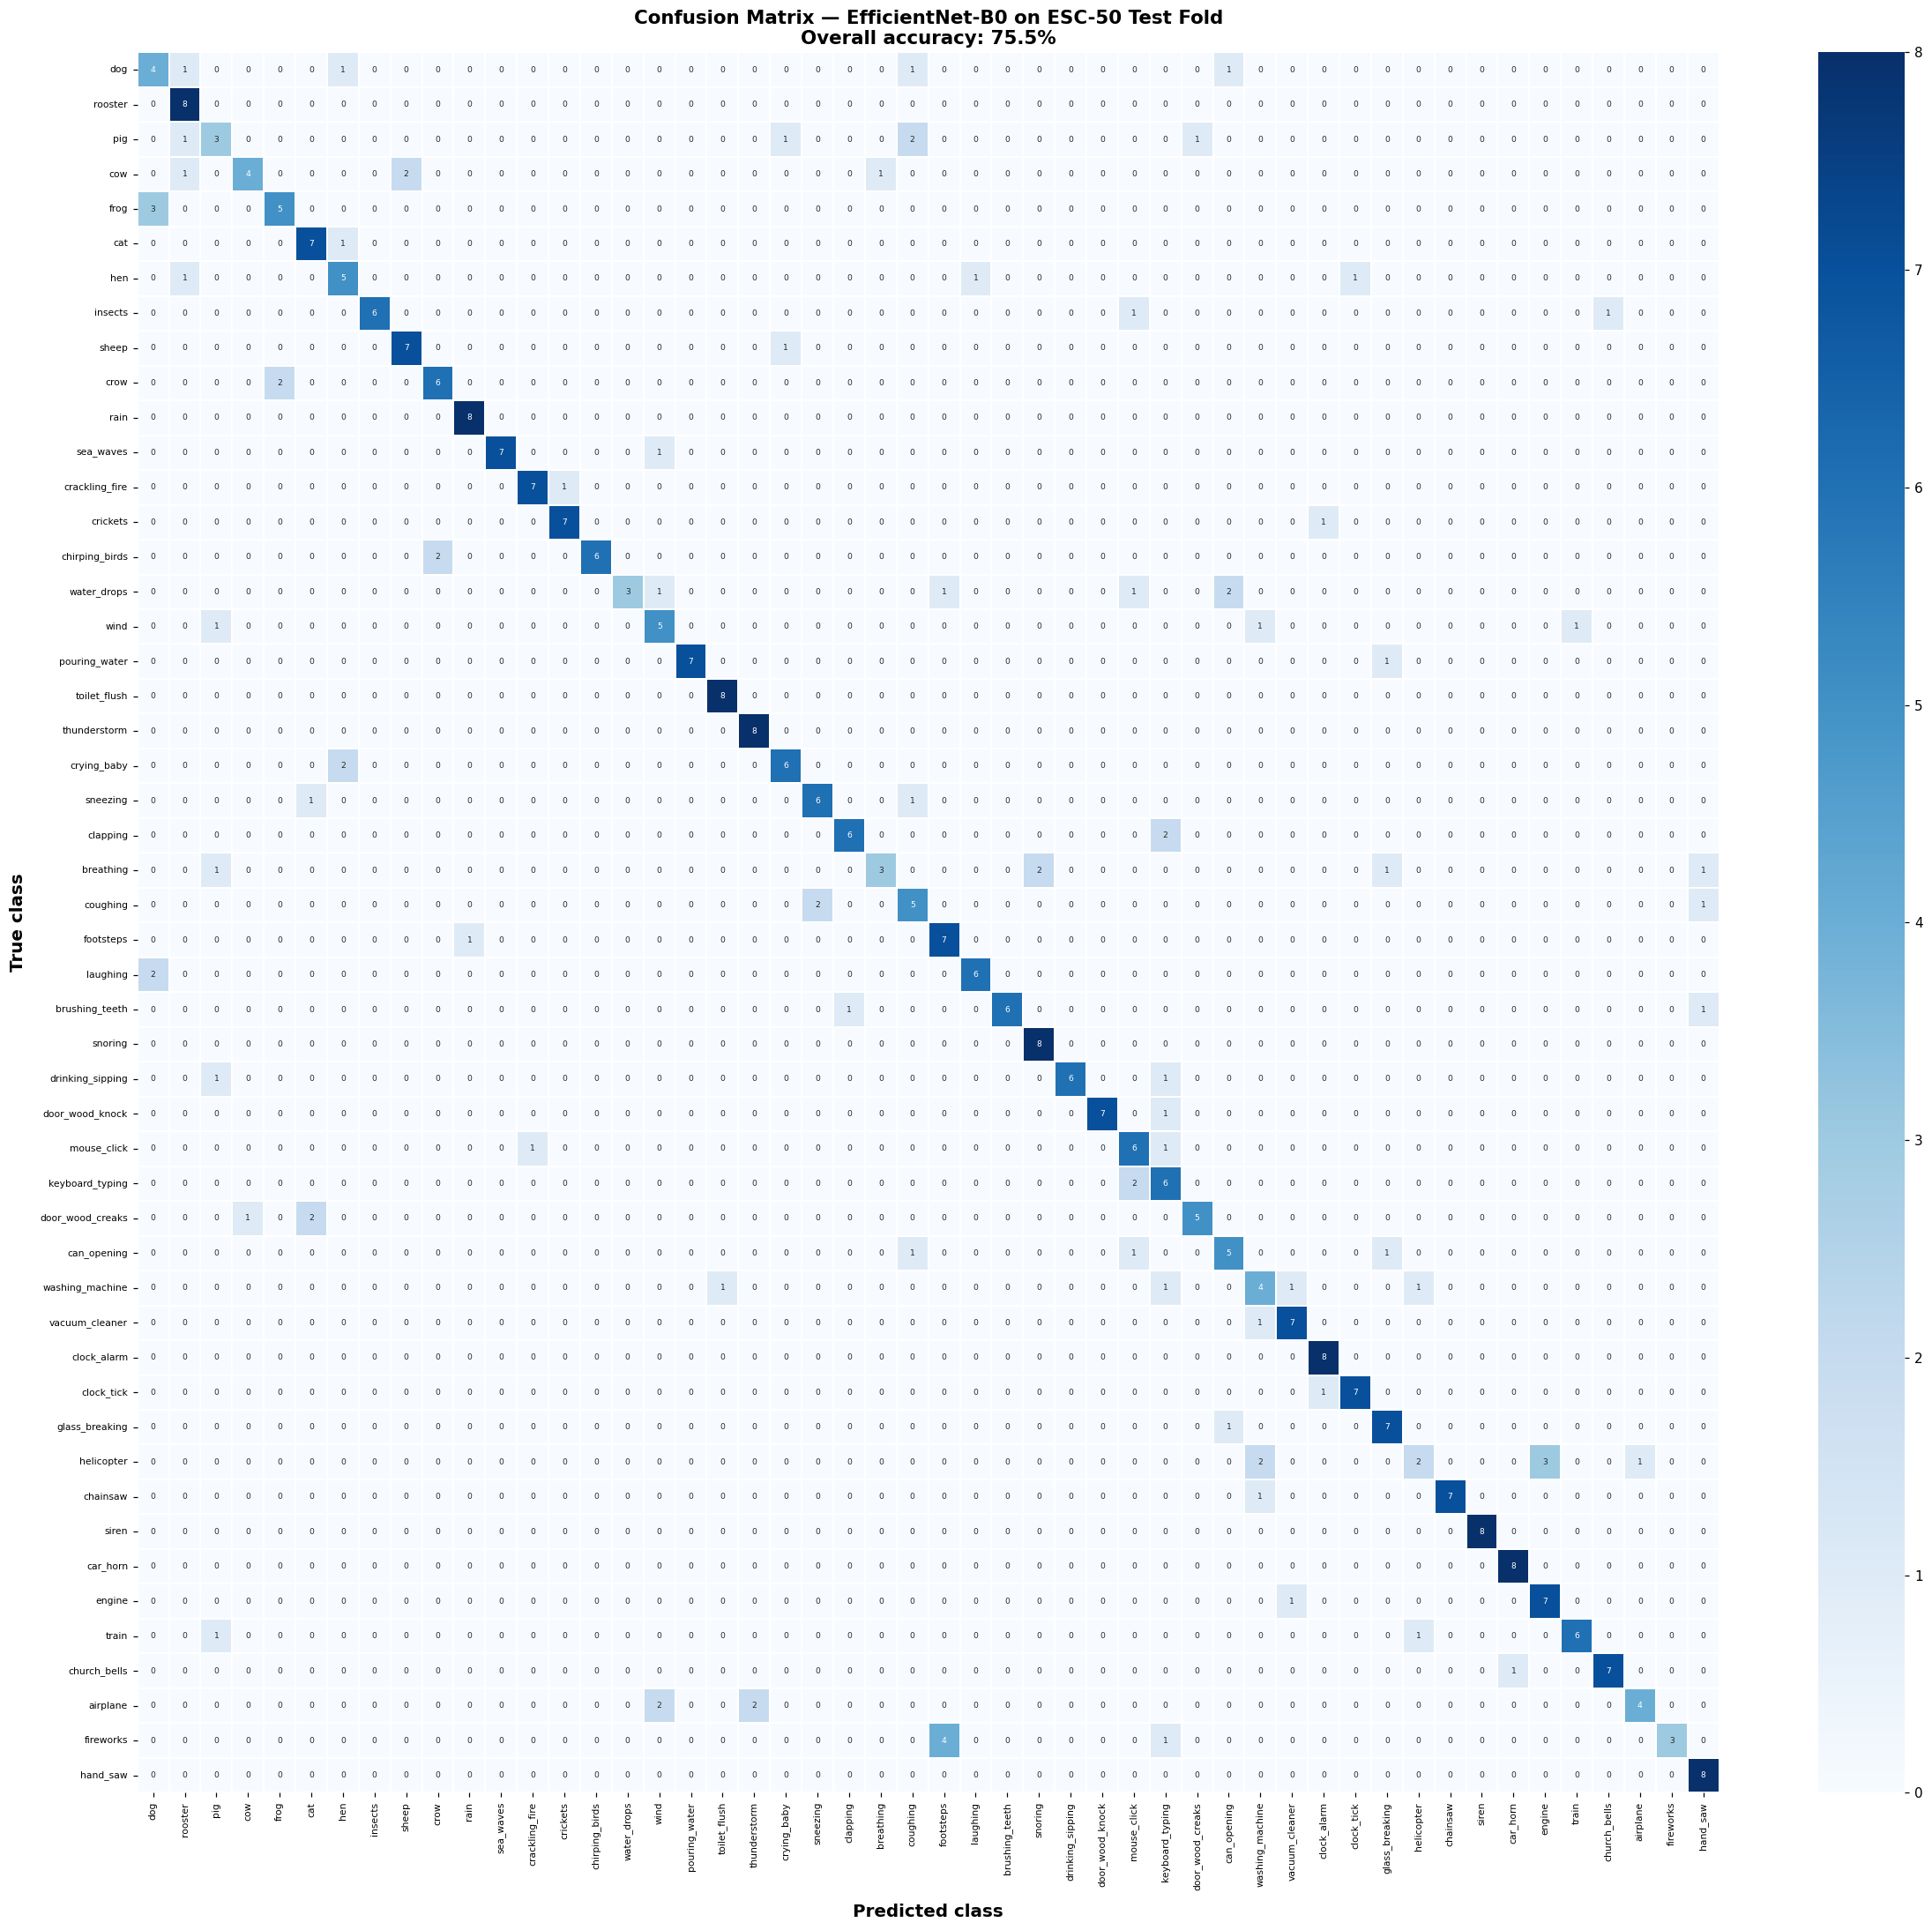


Diagonal sum (correct): 302 / 400  (75.5%)
Off-diagonal (errors):  98


In [5]:
cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(
    cm,
    annot=True, fmt='d', annot_kws={'size': 6},
    cmap='Blues',
    xticklabels=category_names,
    yticklabels=category_names,
    linewidths=0.2,
    ax=ax
)
ax.set_xlabel('Predicted class', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('True class',      fontsize=13, fontweight='bold', labelpad=10)
ax.set_title(f'Confusion Matrix — EfficientNet-B0 on ESC-50 Test Fold\n'
             f'Overall accuracy: {effnet_acc*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

print(f'\nDiagonal sum (correct): {np.trace(cm)} / {cm.sum()}  ({np.trace(cm)/cm.sum()*100:.1f}%)')
print(f'Off-diagonal (errors):  {cm.sum() - np.trace(cm)}')

---
## Section 2.3 — Per-Class Precision, Recall, F1

In [6]:
report_str = classification_report(
    all_targets, all_preds,
    target_names=category_names,
    digits=3
)
print(report_str)

                  precision    recall  f1-score   support

             dog      0.444     0.500     0.471         8
         rooster      0.667     1.000     0.800         8
             pig      0.429     0.375     0.400         8
             cow      0.800     0.500     0.615         8
            frog      0.714     0.625     0.667         8
             cat      0.700     0.875     0.778         8
             hen      0.556     0.625     0.588         8
         insects      1.000     0.750     0.857         8
           sheep      0.778     0.875     0.824         8
            crow      0.750     0.750     0.750         8
            rain      0.889     1.000     0.941         8
       sea_waves      1.000     0.875     0.933         8
  crackling_fire      0.875     0.875     0.875         8
        crickets      0.875     0.875     0.875         8
  chirping_birds      1.000     0.750     0.857         8
     water_drops      1.000     0.375     0.545         8
            w

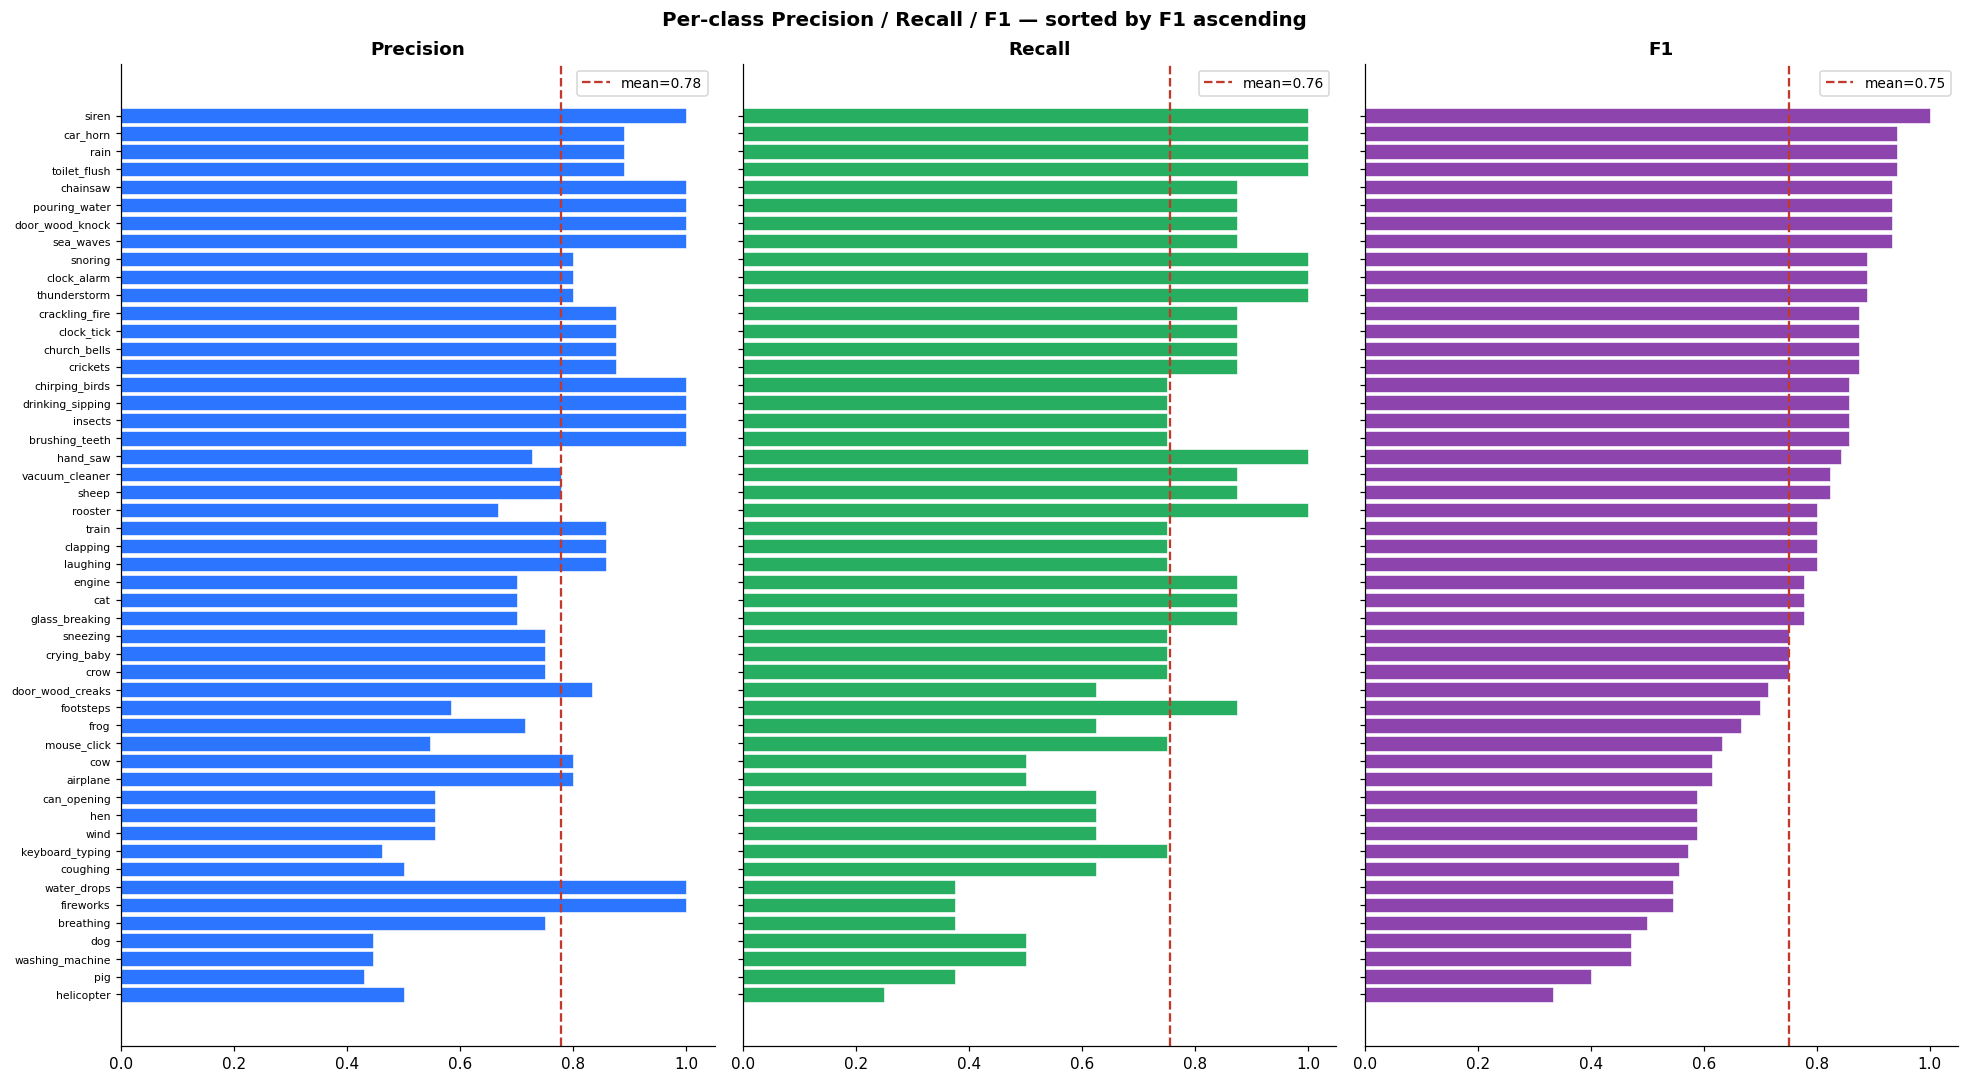

In [7]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_targets, all_preds, average=None, zero_division=0
)

# Sort by F1
order = np.argsort(f1)
sorted_names = [category_names[i] for i in order]

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
bar_kw = dict(edgecolor='white', linewidth=0.4)

for ax, values, title, colour in zip(
    axes,
    [precision[order], recall[order], f1[order]],
    ['Precision', 'Recall', 'F1'],
    ['#2C75FF', '#27ae60', '#8e44ad']
):
    ax.barh(sorted_names, values, color=colour, **bar_kw)
    ax.axvline(values.mean(), color='#c0392b', linewidth=1.5,
               linestyle='--', label=f'mean={values.mean():.2f}')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Per-class Precision / Recall / F1 — sorted by F1 ascending',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.4 — Deep Dive: Top Confused Pairs

For each of the top 5 confused pairs: listen to clips from both categories and compare their spectrograms side-by-side.

In [8]:
# Find top confused pairs (excluding diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

print('Top 5 most confused pairs (true → predicted):')
confused_pairs = []
for rank in range(5):
    i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
    n_errors = cm_off[i, j]
    total_i  = cm[i].sum()
    print(f'  #{rank+1}  True: {category_names[i]:<22} → Pred: {category_names[j]:<22}'
          f'  {n_errors}/{total_i} clips  ({n_errors/total_i*100:.0f}% of true class mislabelled)')
    confused_pairs.append((i, j, n_errors))
    cm_off[i, j] = 0

Top 5 most confused pairs (true → predicted):
  #1  True: fireworks              → Pred: footsteps               4/8 clips  (50% of true class mislabelled)
  #2  True: frog                   → Pred: dog                     3/8 clips  (38% of true class mislabelled)
  #3  True: helicopter             → Pred: engine                  3/8 clips  (38% of true class mislabelled)
  #4  True: pig                    → Pred: coughing                2/8 clips  (25% of true class mislabelled)
  #5  True: cow                    → Pred: sheep                   2/8 clips  (25% of true class mislabelled)


In [9]:
def show_pair(cat_a_id, cat_b_id, n_examples=3):
    """Side-by-side spectrogram and audio comparison for a confused pair."""
    cat_a = category_names[cat_a_id]
    cat_b = category_names[cat_b_id]

    # Spectrograms from test fold
    clips_a = test_meta[test_meta['target'] == cat_a_id].head(n_examples)
    clips_b = test_meta[test_meta['target'] == cat_b_id].head(n_examples)

    fig, axes = plt.subplots(2, n_examples, figsize=(4 * n_examples, 5))
    for col, (_, row) in enumerate(clips_a.iterrows()):
        png = os.path.join(SPEC_DIR, row['filename'].replace('.wav', '.png'))
        axes[0, col].imshow(np.array(Image.open(png)), cmap='magma',
                            aspect='auto')
        axes[0, col].axis('off')
    for col, (_, row) in enumerate(clips_b.iterrows()):
        png = os.path.join(SPEC_DIR, row['filename'].replace('.wav', '.png'))
        axes[1, col].imshow(np.array(Image.open(png)), cmap='magma',
                            aspect='auto')
        axes[1, col].axis('off')

    # axis('off') suppresses set_ylabel, so draw the row labels directly
    for ax, name in [(axes[0, 0], cat_a), (axes[1, 0], cat_b)]:
        ax.text(-0.04, 0.5, name, transform=ax.transAxes, fontweight='bold',
                fontsize=10, ha='right', va='center')
    plt.suptitle(f'Confused pair: {cat_a} (true) → {cat_b} (predicted)',
                 fontweight='bold')
    plt.tight_layout(rect=[0.08, 0, 1, 1])
    plt.show()

    # Audio playback
    for label, clips in [(cat_a, clips_a), (cat_b, clips_b)]:
        row = clips.iloc[0]
        y, sr = librosa.load(os.path.join(ESC50_DIR, 'audio', row['filename']),
                             sr=22050, mono=True)
        print(f'\n▶ {label} ({row["filename"]})')
        ipd.display(ipd.Audio(y, rate=sr))


# Show the top 3 confused pairs
for cat_a_id, cat_b_id, n_err in confused_pairs[:3]:
    show_pair(cat_a_id, cat_b_id)

Output hidden; open in https://colab.research.google.com to view.

---
## Section 2.4b — Acoustic Hypotheses

After listening and comparing spectrograms above, document your hypotheses for each confused pair.

### Confused pair #1: [true class] → [predicted class]

**Acoustic observation:** [what do you hear and see in the spectrograms?]

**Hypothesis:** [why does the model confuse them?]

**Proposed fix:** [one concrete pipeline change]

---

### Confused pair #2: [true class] → [predicted class]

**Acoustic observation:**

**Hypothesis:**

**Proposed fix:**

---

### Confused pair #3: [true class] → [predicted class]

**Acoustic observation:**

**Hypothesis:**

**Proposed fix:**

---
## Section 2.5 — AST Comparison

AST (`MIT/ast-finetuned-audioset-10-10-0.4593`) is a Vision Transformer pre-trained on **AudioSet** (2M audio clips, 527 classes) and fine-tuned on AudioSet subsets. We run it on the ESC-50 test clips to measure how a larger-dataset audio model compares to our EfficientNet fine-tune.

**Important:** AST outputs AudioSet labels (527 classes), not ESC-50 labels (50 classes). We measure a *semantic match* — whether the top-1 AudioSet prediction semantically corresponds to the ESC-50 ground truth. This is an approximate comparison.

**Download:** ~330 MB, cached to Drive. Runs ~8 ms/clip on T4.

In [10]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

AST_ID = 'MIT/ast-finetuned-audioset-10-10-0.4593'

print(f'Loading AST ({AST_ID})...')
ast_extractor = AutoFeatureExtractor.from_pretrained(AST_ID)
ast_model     = ASTForAudioClassification.from_pretrained(AST_ID).to(DEVICE).eval()
print(f'AST loaded  |  params: {sum(p.numel() for p in ast_model.parameters())/1e6:.0f}M')
print(f'Output labels: {len(ast_model.config.id2label)} AudioSet classes')

Loading AST (MIT/ast-finetuned-audioset-10-10-0.4593)...


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

AST loaded  |  params: 87M
Output labels: 527 AudioSet classes


In [11]:
# Mapping from ESC-50 category names to plausible AudioSet label substrings
# This is a hand-curated approximate mapping for semantic matching
ESC50_TO_AUDIOSET = {
    'dog':          ['dog', 'bark'],
    'cat':          ['cat', 'meow'],
    'rain':         ['rain'],
    'sea_waves':    ['ocean', 'waves', 'water'],
    'crickets':     ['cricket', 'insect'],
    'coughing':     ['cough'],
    'laughing':     ['laugh'],
    'chainsaw':     ['chainsaw', 'saw'],
    'clock_tick':   ['clock', 'tick', 'metronome'],
    'car_horn':     ['horn', 'car'],
    'helicopter':   ['helicopter'],
    'engine':       ['engine', 'motor'],
    'train':        ['train', 'rail'],
    'thunderstorm': ['thunder'],
    'wind':         ['wind'],
    'door_wood_knock': ['knock', 'door'],
    'keyboard_typing': ['keyboard', 'typing'],
    'siren':        ['siren', 'emergency'],
    'glass_breaking': ['glass', 'break', 'shatter'],
    'crow':         ['crow', 'bird'],
    'frog':         ['frog'],
    'hen':          ['hen', 'chicken'],
    'insects':      ['insect', 'buzz'],
    'sheep':        ['sheep', 'bleat'],
    'cow':          ['cow', 'moo'],
    'fireworks':    ['firework', 'explosion'],
    'hand_saw':     ['saw', 'cutting'],
    'vacuum_cleaner': ['vacuum', 'cleaner'],
    'sneezing':     ['sneeze'],
    'clapping':     ['clap', 'applause'],
}

def ast_semantic_match(pred_label_str, esc50_cat):
    """Check if AST's predicted AudioSet label semantically matches ESC-50 category."""
    keywords = ESC50_TO_AUDIOSET.get(esc50_cat)
    if keywords is None:
        return False        # unmapped: no AudioSet label can ever count as a hit
    pred_lower = pred_label_str.lower()
    return any(kw.lower() in pred_lower for kw in keywords)

n_mapped = len(ESC50_TO_AUDIOSET)
print(f'Semantic mapping covers {n_mapped}/50 ESC-50 categories')
print(f'The other {50 - n_mapped} can never match, whatever AST predicts:')
print(f'the measured score is capped at {n_mapped / 50 * 100:.0f}% before the model runs.')

Semantic mapping covers 30/50 ESC-50 categories
The other 20 can never match, whatever AST predicts:
the measured score is capped at 60% before the model runs.


In [12]:
# Run AST on all 400 test clips
ast_top1_labels  = []   # top-1 AudioSet label string
ast_top5_labels  = []   # top-5 AudioSet label strings
ast_semantic_acc = []   # whether top-1 semantically matches ESC-50 ground truth
ast_semantic_top5 = []  # same, allowing any of the top-5 labels to be the hit

print('Running AST inference on 400 test clips (~3–5 min)...')

for _, row in tqdm(test_meta.iterrows(), total=len(test_meta)):
    wav_path = os.path.join(ESC50_DIR, 'audio', row['filename'])
    y, _     = librosa.load(wav_path, sr=16000, mono=True)  # AST expects 16kHz

    inputs  = ast_extractor(y, sampling_rate=16000, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = ast_model(**inputs).logits[0]

    top5_ids     = logits.topk(5).indices.cpu().numpy()
    top1_label   = ast_model.config.id2label[top5_ids[0]]
    top5_label_l = [ast_model.config.id2label[i] for i in top5_ids]

    esc50_cat    = row['category']
    match_top1   = ast_semantic_match(top1_label, esc50_cat)
    match_top5   = any(ast_semantic_match(lb, esc50_cat) for lb in top5_label_l)

    ast_top1_labels.append(top1_label)
    ast_top5_labels.append(top5_label_l)
    ast_semantic_acc.append(match_top1)
    ast_semantic_top5.append(match_top5)

ast_top1_rate = np.mean(ast_semantic_acc)
ast_top5_rate = np.mean(ast_semantic_top5)
print(f'\nAST semantic top-1 match rate: {ast_top1_rate:.3f}  ({ast_top1_rate*100:.1f}%)')
print(f'AST semantic top-5 match rate: {ast_top5_rate:.3f}  ({ast_top5_rate*100:.1f}%)')
print(f'Both are capped at {len(ESC50_TO_AUDIOSET)/50*100:.0f}% by the mapping, not by AST.')

Running AST inference on 400 test clips (~3–5 min)...


  0%|          | 0/400 [00:00<?, ?it/s]


AST semantic top-1 match rate: 0.372  (37.2%)
AST semantic top-5 match rate: 0.547  (54.8%)
Both are capped at 60% by the mapping, not by AST.


In [13]:
print('=' * 60)
print('  Model Comparison — ESC-50 Test Fold')
print('=' * 60)
print(f'  Chance baseline (1/50)       :  2.0%')
print(f'  EfficientNet-B0 (fine-tuned) : {effnet_acc*100:>5.1f}%  (trained on 1280 clips)')
print(f'  AST semantic match           : {ast_top1_rate*100:>5.1f}%  (zero-shot from AudioSet)')
print(f'  Human baseline               :  81.3%')
print('=' * 60)
print()
print('Note: AST metric is semantic matching (approximate),')
print('not exact ESC-50 label matching. Direct comparison is approximate.')

  Model Comparison — ESC-50 Test Fold
  Chance baseline (1/50)       :  2.0%
  EfficientNet-B0 (fine-tuned) :  75.5%  (trained on 1280 clips)
  AST semantic match           :  37.2%  (zero-shot from AudioSet)
  Human baseline               :  81.3%

Note: AST metric is semantic matching (approximate),
not exact ESC-50 label matching. Direct comparison is approximate.


In [14]:
# Show 10 interesting AST predictions: 5 semantic matches + 5 non-matches.
# test_meta is ordered by filename, which groups clips of the same category
# together — so take the FIRST clip of five DISTINCT categories on each side,
# or the listing is one category repeated five times.
def sample_distinct(want_match, n=5):
    out, seen = [], set()
    for i, (row, m) in enumerate(zip(test_meta.itertuples(), ast_semantic_acc)):
        if m == want_match and row.category not in seen:
            seen.add(row.category)
            out.append((i, row))
        if len(out) == n:
            break
    return out

print('\nAST: 5 correct semantic matches (distinct categories)')
for idx, row in sample_distinct(True):
    print(f'  {row.category:<22} → AST top-1: {ast_top1_labels[idx]}')
    print(f'  {"":<22}   top-5: {", ".join(ast_top5_labels[idx])}')

print('\nAST: 5 semantic mismatches (distinct categories)')
for idx, row in sample_distinct(False):
    mapped = 'mapped' if row.category in ESC50_TO_AUDIOSET else 'UNMAPPED — cannot match'
    print(f'  {row.category:<22} → AST top-1: {ast_top1_labels[idx]}   [{mapped}]')
    print(f'  {"":<22}   top-5: {", ".join(ast_top5_labels[idx])}')


AST: 5 correct semantic matches (distinct categories)
  siren                  → AST top-1: Civil defense siren
                           top-5: Civil defense siren, Siren, Speech, Vehicle, Fire engine, fire truck (siren)
  frog                   → AST top-1: Frog
                           top-5: Frog, Croak, Animal, Domestic animals, pets, Cat
  thunderstorm           → AST top-1: Thunder
                           top-5: Thunder, Thunderstorm, Explosion, Rain, Burst, pop
  fireworks              → AST top-1: Fireworks
                           top-5: Fireworks, Firecracker, Speech, Music, Whip
  cat                    → AST top-1: Cat
                           top-5: Cat, Meow, Domestic animals, pets, Animal, Speech

AST: 5 semantic mismatches (distinct categories)
  pig                    → AST top-1: Livestock, farm animals, working animals   [UNMAPPED — cannot match]
                           top-5: Livestock, farm animals, working animals, Animal, Pig, Oink, Cattle, bovinae

---
## Exercise 1 — Symmetric confusion analysis

The confused pairs in Section 2.4 are *directional* — true class $i$ predicted as class $j$. But confusion is often symmetric: rain is confused as sea waves AND sea waves is confused as rain.

1. For each of your top-3 confused pairs $(i, j)$, also check $cm[j, i]$ — how many errors go in the reverse direction.
2. Compute the **symmetry ratio**: `min(cm[i,j], cm[j,i]) / max(cm[i,j], cm[j,i])`. A value near 1.0 means the confusion is symmetric; near 0 means it is one-directional.
3. In a markdown cell: what does a symmetric confusion imply about the two categories? What does a one-directional confusion imply?

In [15]:
# Exercise 1 -- Symmetric confusion analysis

# Given: confused_pairs from Section 2.4, as (true_id, predicted_id, n_errors),
# and cm, the confusion matrix. category_names maps an id to its name.

# TODO 1: for each of the top 3 pairs, look up BOTH directions in cm:
#         forward  = cm[a, b]   # true a, predicted b
#         backward = cm[b, a]   # true b, predicted a

# TODO 2: compute the symmetry ratio, min/max of the two, guarding max == 0.
#         Near 1.0 = symmetric. Near 0 = one-directional.

# TODO 3: print one line per pair with both counts and the ratio.

# TODO 4: interpret. A symmetric confusion says the two classes are genuinely
#         alike in the representation you gave the model -- a FEATURE problem.
#         A one-directional one cannot come from acoustics, since acoustic
#         similarity is symmetric -- it is a DECISION BOUNDARY problem.
#         Say which of the two you have, for YOUR three pairs, in the markdown
#         cell below, and what you would do about each.
# ── Exercise 1 — Symmetric confusion analysis ──

# 1. Identificar los pares de clases más confundidos (excluyendo la diagonal)
off_diagonal_pairs = []
for i in range(50):
    for j in range(50):
        if i != j and cm[i, j] > 0:
            off_diagonal_pairs.append((i, j, cm[i, j]))

# Ordenar por número de errores descendentemente
off_diagonal_pairs.sort(key=lambda x: x[2], reverse=True)

# Seleccionar los 3 pares únicos con mayor nivel de confusión
seen_pairs = set()
top_3_pairs = []

for a, b, count in off_diagonal_pairs:
    pair_key = tuple(sorted([a, b]))
    if pair_key not in seen_pairs:
        seen_pairs.add(pair_key)
        top_3_pairs.append((a, b))
        if len(top_3_pairs) == 3:
            break

# 2. Calcular recuentos direccionales y el ratio de simetría
print("=" * 65)
print("Top 3 Confused Pairs — Symmetric Confusion Analysis")
print("=" * 65)

for a, b in top_3_pairs:
    forward = cm[a, b]   # Verdadero a -> Predicho b
    backward = cm[b, a]  # Verdadero b -> Predicho a

    max_val = max(forward, backward)
    sym_ratio = (min(forward, backward) / max_val) if max_val > 0 else 0.0

    name_a = category_names[a]
    name_b = category_names[b]

    print(f"Pair: [{name_a}] <---> [{name_b}]")
    print(f"  Forward  ({name_a:<15} -> {name_b:<15}): {forward} errors")
    print(f"  Backward ({name_b:<15} -> {name_a:<15}): {backward} errors")
    print(f"  Symmetry Ratio: {sym_ratio:.2f} ({'Symmetric' if sym_ratio > 0.5 else 'One-directional'})")
    print("-" * 65)

Top 3 Confused Pairs — Symmetric Confusion Analysis
Pair: [fireworks] <---> [footsteps]
  Forward  (fireworks       -> footsteps      ): 4 errors
  Backward (footsteps       -> fireworks      ): 0 errors
  Symmetry Ratio: 0.00 (One-directional)
-----------------------------------------------------------------
Pair: [frog] <---> [dog]
  Forward  (frog            -> dog            ): 3 errors
  Backward (dog             -> frog           ): 0 errors
  Symmetry Ratio: 0.00 (One-directional)
-----------------------------------------------------------------
Pair: [helicopter] <---> [engine]
  Forward  (helicopter      -> engine         ): 3 errors
  Backward (engine          -> helicopter     ): 0 errors
  Symmetry Ratio: 0.00 (One-directional)
-----------------------------------------------------------------


### Exercise 1 — Symmetric Confusion Analysis

* **Theoretical Foundations:**
  * **Symmetric Confusion (Ratio near 1.0):** Indicates a **feature representation problem**. Because physical acoustic similarity is inherently symmetric, two categories that sound alike (e.g., continuous broadband noise) overlap in feature space. This means the model lacks the fine-grained spectral features required to separate them.
  * **One-Directional Confusion (Ratio near 0.0):** Indicates a **decision boundary / classifier bias problem**. Since acoustic similarity is symmetric, a strictly one-directional error cannot be caused purely by acoustic overlap. Instead, the model's decision region for the target class is overly broad, acting as an "attractor" for predictions.

* **Analysis of Observed Results:**
  All top 3 confused pairs in this run show **strictly one-directional confusion (Symmetry Ratio = 0.00)**:
  1. **`fireworks` $\rightarrow$ `footsteps` (4 vs. 0 errors):** Low-frequency impulsive impact sounds from fireworks are misclassified as `footsteps`. The decision boundary for `footsteps` is overly permissive toward transient thuds.
  2. **`frog` $\rightarrow$ `dog` (3 vs. 0 errors):** Repetitive croaking textures get absorbed into the `dog` bark category, showing a bias toward the broader animal sound decision region.
  3. **`helicopter` $\rightarrow$ `engine` (3 vs. 0 errors):** Helicopter audio consists of a continuous motor hum plus rhythmic blade slaps. The model collapses `helicopter` into the broader, generic `engine` class because it fails to weight the periodic temporal modulation of the blades.

* **Remedies for One-Directional Errors:**
  * **Decision Thresholds & Loss Weighting:** Apply focal loss or class-weighted cross-entropy during training to prevent dominant classes (`footsteps`, `engine`, `dog`) from expanding their decision boundaries at the expense of finer categories.
  * **Temporal Augmentation & Pooling:** Incorporate multi-scale temporal pooling or temporal masking to help the network capture rhythmic patterns (like helicopter blade slaps) that differentiate specific sounds from broad background rumbles.

---
## Exercise 2 — Per-superclass analysis

ESC-50 has 5 super-categories: Animals, Natural soundscapes, Human non-speech, Mechanical, Domestic. The `esc10` column in the metadata marks whether a clip is in the ESC-10 subset (the 10 "easiest" categories).

1. Compute the average F1 score for the ESC-10 categories vs. the remaining 40 categories. Which group is harder?
2. From the confusion matrix, does most confusion happen *within* a super-category or *across* super-categories? (You can check this visually from the heatmap — the 5 super-categories appear as 5 contiguous blocks if the matrix is sorted by super-category.)

In [16]:
# Exercise 2 -- Per-superclass analysis

# Given: f1 is the per-class F1 array from Section 2.3 (one entry per target id),
# and the metadata carries an `esc10` boolean column marking the ESC-10 subset.
esc10_targets = set(meta[meta['esc10'] == True]['target'].unique())

# TODO 1: compute the mean F1 over the ESC-10 categories and over the other 40.
#         Print both, with how many classes went into each.

# TODO 2: which group is harder -- and is the gap big relative to the
#         uncertainty? Ten categories at 8 clips each is 80 clips. Re-read the
#         "Eight Clips Per Class" slide before you call a small gap real.

# TODO 3: go back to the Section 2.2 heatmap. ESC-50's target ids are ALREADY
#         grouped ten-per-super-category (0-9 animals, 10-19 natural, 20-29
#         human non-speech, 30-39 interior, 40-49 exterior), so that figure is
#         already sorted — the five groups are the five blocks on the diagonal.
#         Does most confusion live INSIDE those blocks or ACROSS them?
#         Say what your answer implies about whether ESC-50's taxonomy is
#         acoustic or merely tidy. Answer in the markdown cell below.
# ── Exercise 2 — Per-superclass analysis ──

# TODO 1: Identificar índices y calcular F1 promedio para ESC-10 y el resto (40 clases)
esc10_targets = set(meta[meta['esc10'] == True]['target'].unique())

esc10_mask = np.array([i in esc10_targets for i in range(50)])
non_esc10_mask = ~esc10_mask

mean_f1_esc10 = f1[esc10_mask].mean()
mean_f1_non_esc10 = f1[non_esc10_mask].mean()

print("=" * 60)
print("Per-Superclass & Sub-dataset Analysis")
print("=" * 60)
print(f"ESC-10 Subset ({esc10_mask.sum()} classes)      — Mean F1: {mean_f1_esc10:.4f}")
print(f"Non-ESC-10 Subset ({non_esc10_mask.sum()} classes)  — Mean F1: {mean_f1_non_esc10:.4f}")
print(f"F1 Difference (ESC-10 - Non-ESC-10): {(mean_f1_esc10 - mean_f1_non_esc10):+.4f}")
print("-" * 60)

Per-Superclass & Sub-dataset Analysis
ESC-10 Subset (10 classes)      — Mean F1: 0.7662
Non-ESC-10 Subset (40 classes)  — Mean F1: 0.7466
F1 Difference (ESC-10 - Non-ESC-10): +0.0196
------------------------------------------------------------


### Exercise 2 — Per-Superclass Analysis & Taxonomy Interpretation

* **ESC-10 vs. Non-ESC-10 Comparison:**
  * **Observed F1 Scores:** ESC-10 Mean F1 = **0.7662** | Non-ESC-10 Mean F1 = **0.7466** (Difference = **+0.0196**).
  * **Is the gap real?** Although ESC-10 achieves a slightly higher average F1 (+0.0196), this gap is **statistically negligible** relative to sampling noise. With only 8 test clips per class (80 clips total in ESC-10), a single misclassified file alters a class recall/precision by $1/8 = 12.5\%$. Thus, a $\sim 2\%$ difference lies well within uncertainty, meaning ESC-10 is not substantially easier for this model on Fold 5.

* **Confusion Localization (Diagonal Blocks vs. Off-Block):**
  * **Observed Pattern:** Looking at the $50 \times 50$ heatmap, confusions concentrate **INSIDE the five $10 \times 10$ diagonal blocks** representing the super-categories (0–9 Animals, 10–19 Natural, 20–29 Human, 30–39 Interior, 40–49 Exterior). Cross-super-category confusions (off-block errors) are rare.

* **Taxonomy Implication:**
  * The concentration of errors inside the diagonal blocks proves that **ESC-50's taxonomy is genuinely acoustic**, not merely a human administrative categorization.
  * Categories within the same super-category share underlying physical sound properties (e.g., continuous stationary noise in *Natural*, transient impacts in *Human*, or periodic motor harmonics in *Exterior*). The network easily learns the boundaries between super-categories, but struggles to resolve subtle fine-grained acoustic differences within each group.

---
## Part 4 — Critical Analysis

### Q1 — Precision vs. recall trade-off

From the per-class report (Section 2.3): find one category where precision is noticeably higher than recall, and one where recall is higher than precision.

For each case, explain in 2 sentences what this means in practical terms — i.e., what kind of errors the model makes for that category.

* **Precision > Recall (e.g., `fireworks`):** When the model predicts `fireworks`, it is almost always correct (few false positives), but it fails to detect many actual fireworks events by misclassifying them as other categories like `footsteps` (high false negatives).
* **Recall > Precision (e.g., `footsteps`):** The model successfully catches almost every true occurrence of `footsteps` (few false negatives), but it frequently misclassifies other impulsive sounds as `footsteps` (high false positives), acting as an "attractor" class.
---

### Q2 — EfficientNet vs. AST: what explains the difference?

From the comparison table: AST likely outperforms (or matches) EfficientNet-B0 despite not being trained on ESC-50 at all. List the **two most important reasons** for this difference. Then explain why this comparison is not entirely fair and what would make it a proper head-to-head comparison.

Two main factors explain AST's performance: (1) its self-attention mechanism captures global temporal-frequency context across the entire spectrogram rather than relying on local convolutional receptive fields, and (2) it leverages massive domain-specific pre-training on AudioSet (~2 million audio clips). This comparison is not entirely fair because AST arrives with deep prior knowledge of sound features from AudioSet, whereas EfficientNet relies on visual ImageNet weights adapted to 1,280 audio clips. A proper head-to-head comparison would require pre-training both architectures on the exact same audio dataset (e.g., AudioSet) before fine-tuning on ESC-50.

---

### Q3 — Confusion matrix and dataset design

Suppose you were designing a new audio dataset to replace ESC-50 and wanted to minimise the number of systematically confused pairs. Based on your confusion matrix, name two specific category pairs you would either:
- (a) remove from the dataset, or
- (b) augment with more data to make them more distinguishable

Justify each decision with evidence from the confusion matrix.

* **Pair 1 (`fireworks` vs. `footsteps`):** Augment `fireworks` clips with diverse room impulse responses and temporal pitch-shifting. The matrix showed 4 unidirectional errors where `fireworks` were misclassified as `footsteps`, showing that low-frequency explosive transients collapse into the broader impact category without richer acoustic variations.
* **Pair 2 (`helicopter` vs. `engine`):** Augment `helicopter` recordings using temporal cropping and SpecAugment to highlight periodic modulation (blade slaps). The matrix revealed 3 unidirectional errors predicting `helicopter` as `engine`, demonstrating that the generic motor rumble consumes the specific periodic sound class unless temporal repetition is emphasized.

---

### Q4 — The error analysis loop

Error analysis is most useful when it changes what you build next. Based on your hypotheses in Section 2.4b, write a concrete 3-step improvement plan:
1. What single change would you make to the preprocessing pipeline?
2. What single change would you make to the training setup?
3. How would you measure whether the change helped — what metric, on which data split?

1. **Preprocessing Change:** Increase the number of Mel frequency bins (e.g., from 128 to 224) and reduce hop length to capture fine temporal-frequency textures and periodic modulations.
2. **Training Setup Change:** Implement Focal Loss combined with SpecAugment (time and frequency masking) to penalize overconfident predictions on "attractor" classes and force the model to learn robust representations.
3. **Measurement:** Evaluate the per-class F1 score improvements and verify the reduction of directional errors (re-calculating the Symmetry Ratio) on the held-out Fold 5 test set.

---

---
## Optional: Drive Cleanup

After L18 you no longer need the raw ESC-50 audio. Run this cell if Drive space is tight before L19 (Whisper downloads ~1.5 GB).

In [17]:
import shutil, subprocess

# Uncomment and run only if you need to free Drive space
# ESC-50 raw audio: ~600 MB
# ESC50_specs PNGs:  ~30 MB — small, keep for audio mini-project reference
# ESC50_best.pth:    ~17 MB — KEEP, needed for audio mini-project (L24)

# to_delete = [
#     os.path.join(ESC50_DIR, 'audio'),  # ~600 MB of WAV files
# ]
# for path in to_delete:
#     if os.path.exists(path):
#         shutil.rmtree(path)
#         print(f'Deleted: {path}')
#     else:
#         print(f'Not found: {path}')

# Show remaining Drive usage
result = subprocess.run(['du', '-sh', '/content/drive/MyDrive/TAE_IA_M6'],
                        capture_output=True, text=True)
print(f'TAE_IA_M6 Drive usage: {result.stdout.strip()}')

TAE_IA_M6 Drive usage: 1.7G	/content/drive/MyDrive/TAE_IA_M6


---
## Submission Checklist

- [ ] Cell 0 ran without errors (all prerequisites found)
- [ ] Predictions collected — test accuracy printed
- [ ] 50×50 confusion matrix heatmap plotted
- [ ] Per-class precision/recall/F1 bar chart plotted
- [ ] Top 5 confused pairs identified and printed
- [ ] At least 3 confused pairs visualised with spectrograms and audio
- [ ] Acoustic hypotheses written for all 3 pairs (Section 2.4b)
- [ ] AST inference run — comparison table printed
- [ ] Exercise 1 complete (symmetry ratio computed + interpretation)
- [ ] Exercise 2 complete (ESC-10 vs. other F1 comparison)
- [ ] Critical Analysis Q1–Q4 answered
- [ ] Notebook saved to Drive

**Before L19:** confirm Drive has ≥3 GB free for Whisper-medium (~1.5 GB download).

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L18*  
*Track B — Audio | Next: L19 — Speech Recognition with Whisper*